In [ ]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

base_path = '/content/drive/My Drive/CMPE 255 Data Mining/Dataset'

print(f"Listing contents of '{base_path}':")
if os.path.exists(base_path):
    for item in os.listdir(base_path):
        print(item)
else:
    print(f"Error: The path '{base_path}' does not exist. Please check the folder name and structure in your Google Drive.")

# Read the identified JSON file into a pandas DataFrame
file_name = 'renttherunway_final_data.json'
json_file_path = os.path.join(base_path, file_name)

if os.path.exists(json_file_path):
    try:
        # Added lines=True to handle JSON Lines format
        df = pd.read_json(json_file_path, lines=True)
        print(f"\nSuccessfully loaded '{file_name}' into a pandas DataFrame.")
        print("First 5 rows of the DataFrame:")
        display(df.head())
    except Exception as e:
        print(f"Error reading JSON file '{file_name}': {e}")
else:
    print(f"Error: The file '{json_file_path}' does not exist.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Listing contents of '/content/drive/My Drive/CMPE 255 Data Mining/Dataset':
renttherunway_final_data.json

Successfully loaded 'renttherunway_final_data.json' into a pandas DataFrame.
First 5 rows of the DataFrame:


,fit,user_id,bust size,item_id,weight,rating,rented for,review_text,body type,review_summary,category,height,size,age,review_date
0,fit,420272,34d,2260466,137lbs,10.0,vacation,An adorable romper! Belt and zipper were a lit...,hourglass,So many compliments!,romper,"5' 8""",14,28.0,"April 20, 2016"
1,fit,273551,34b,153475,132lbs,10.0,other,I rented this dress for a photo shoot. The the...,straight & narrow,I felt so glamourous!!!,gown,"5' 6""",12,36.0,"June 18, 2013"
2,fit,360448,NaN,1063761,NaN,10.0,party,This hugged in all the right places! It was a ...,NaN,It was a great time to celebrate the (almost) ...,sheath,"5' 4""",4,116.0,"December 14, 2015"
3,fit,909926,34c,126335,135lbs,8.0,formal affair,I rented this for my company's black tie award...,pear,Dress arrived on time and in perfect condition.,dress,"5' 5""",8,34.0,"February 12, 2014"
4,fit,151944,34b,616682,145lbs,10.0,wedding,I have always been petite in my upper body and...,athletic,Was in love with this dress !!!,gown,"5' 9""",12,27.0,"September 26, 2016"


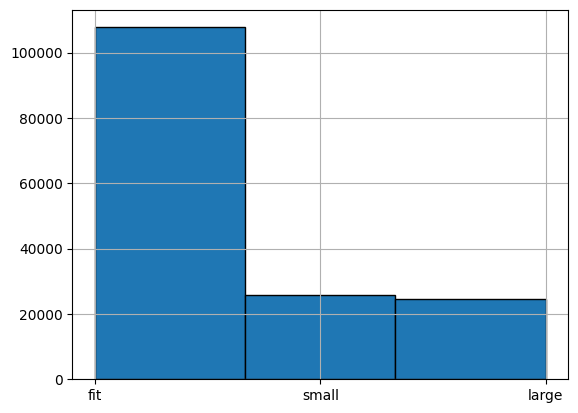

In [6]:
target_feature = 'fit'
n_classes = df[target_feature].unique().shape[0]
df[target_feature].hist(bins=n_classes, edgecolor='black');

In [ ]:
#checking for null values and dropping them.
def check_nulls(data):
    for col in df:
        print(f'Column \'{col}\'. Is null - {data[col].isnull().sum()}')


to_drop = df[df['fit'] == 'fit'].isnull().any(axis=1)
n = to_drop.sum()
to_drop.shape, df.shape
df = df.drop(df[df['fit'] == 'fit'][to_drop].index, axis=0)
print(f'Dropped {n} examples')

check_nulls(df)

In [7]:
#converting height from feet to inches
def parse_ht(height):
    ht_ = height.split("' ")
    ft_ = float(ht_[0])
    in_ = float(ht_[1].replace("\"",""))
    return (12*ft_) + in_
#converting weight from pounds to kilos.
def pounds_to_kilos(s):
    return int(s.replace('lbs', '')) * 0.45359237

df['height'] = (df['height']
                        .fillna("0' 0\"")
                        .apply(parse_ht))
df['height'][df['height'] == 0] = df['height'].median()

df['weight'] = (df['weight']
                        .fillna('0lbs')
                        .apply(pounds_to_kilos))
df['weight'][df['weight'] == 0.0] = df['weight'].median()

df['user_id'] = pd.to_numeric(df['user_id'])
df['bust size'] = df['bust size'].fillna(df['bust size'].value_counts().index[0])
df['body type'] = df['body type'].fillna(df['body type'].value_counts().index[0])
df['item_id'] = pd.to_numeric(df['item_id'])
df['size'] = pd.to_numeric(df['size'])

df['age'] = pd.to_numeric(df['age'])
df['age'] = df['age'].fillna(df['age'].median())

df['rating'] = pd.to_numeric(df['rating'])
df['rating'] = df['rating'].fillna(df['rating'].median())

df['review_date'] = pd.to_datetime(df['review_date'], format='%B %d, %Y')
#replacing null values of numeric features with median values.
df.info()

/tmp/ipykernel_9247/3042125969.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['height'][df['height'] == 0] = df['height'].median()
/tmp/ipykernel_9247/3042125969.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy 

<class 'pandas.core.frame.DataFrame'>
Index: 158219 entries, 0 to 192543
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   fit             158219 non-null  object        
 1   user_id         158219 non-null  int64         
 2   bust size       158219 non-null  object        
 3   item_id         158219 non-null  int64         
 4   weight          158219 non-null  float64       
 5   rating          158219 non-null  float64       
 6   rented for      158218 non-null  object        
 7   review_text     158219 non-null  object        
 8   body type       158219 non-null  object        
 9   review_summary  158219 non-null  object        
 10  category        158219 non-null  object        
 11  height          158219 non-null  float64       
 12  size            158219 non-null  int64         
 13  age             158219 non-null  float64       
 14  review_date     158219 non-null  datetime

In [8]:
#column mapper
col_mapper = {
    'bust size': 'bust_size',
    'weight': 'usr_weight_kg',
    'rating': 'review_rating',
    'rented for': 'rented_for',
    'body type': 'body_type',
    'category': 'product_category',
    'height': 'usr_height_inchs',
    'size': 'product_size',
    'age': 'usr_age',
}
df.rename(col_mapper, axis=1, inplace=True)

In [9]:
newdf = df.copy()